<a href="https://colab.research.google.com/github/Hendersongit/Primeiros-aprendizados-de-Python-em-DataScience/blob/main/Proj_de_DataScience_livro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Predição de bons pagadores de cartão de crédito

## 1. Bibliotecas

In [ ]:
import pandas as pd

## 2. Carregando dados





In [ ]:
URL = ("https://github.com/TrainingByPackt/Data-Science-Projects-with-Python/raw/refs/heads/master/Data/default_of_credit_card_clients__courseware_version_1_21_19.xls")
df = pd.read_excel(URL)

In [ ]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df.shape

(30000, 25)

## 3. Verificando a integridade dos dados

### 3.1 Verificando as colunas

In [ ]:
print("Total de colunas"), len(df.columns),
df.columns

Total de colunas


Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [ ]:
len(df.columns)

25

### 3.1.1 Dicionário de Dados

Este estudo utilizou uma variável binária, inadimplência no pagamento (Sim = 1, Não = 0), como variável resposta. A pesquisa revisou a literatura e utilizou as seguintes 23 variáveis como variáveis explicativas:

X1: Valor do crédito concedido (em dólar taiwanês - NT): inclui tanto o crédito individual do consumidor quanto o crédito familiar (suplementar).
X2: Gênero (1 = masculino; 2 = feminino).
X3: Escolaridade (1 = pós-graduação; 2 = ensino superior; 3 = ensino médio; 4 = outros).
X4: Estado civil (1 = casado; 2 = solteiro; 3 = outros).
X5: Idade (anos).
X6 – X11: Histórico de pagamentos anteriores. Foram considerados os registros mensais de pagamento de abril a setembro de 2005, da seguinte forma:
X6: status de pagamento em setembro de 2005
X7: status de pagamento em agosto de 2005
X11: status de pagamento em abril de 2005
A escala utilizada para o status de pagamento é:
-1: pagamento em dia
1: atraso de um mês
2: atraso de dois meses
8: atraso de oito meses
9: atraso de nove meses ou mais
X12 – X17: Valor da fatura (em dólar taiwanês - NT).
X12: valor da fatura em setembro de 2005
X13: valor da fatura em agosto de 2005
X17: valor da fatura em abril de 2005
X18 – X23: Valor dos pagamentos anteriores (em dólar taiwanês - NT).
X18: valor pago em setembro de 2005
X19: valor pago em agosto de 2005
X23: valor pago em abril de 2005

###3.2 Dando uma olhada nos nossos dados

In [ ]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


###3.3 Verificando se todos os IDs são únicos

In [ ]:
df["ID"].nunique()

29687

###3.4 Verificando o total de linhas

In [ ]:
df.shape[0]

30000

### 3.5 Contagem de IDs

In [ ]:
id_counts = df['ID'].value_counts()
id_counts.head()

,count
ID,
89f8f447-fca8,2
7c9b7473-cc2f,2
90330d02-82d9,2
75938fec-e5ec,2
2a793ecf-05c6,2


###3.6 Contagem de repetições

In [ ]:
id_counts.value_counts()

,count
count,
1,29374
2,313


In [ ]:
29374 + 313*2

30000

##4. Análise de Dados duplicados

### 4.1 IDs que se repetem

In [ ]:
dupe_mask = id_counts == 2
dupe_mask[:5]


,count
ID,
89f8f447-fca8,True
7c9b7473-cc2f,True
90330d02-82d9,True
75938fec-e5ec,True
2a793ecf-05c6,True


###4.2 Exibindo os 5 primeiros índices

In [ ]:
id_counts.index[:5]


Index(['89f8f447-fca8', '7c9b7473-cc2f', '90330d02-82d9', '75938fec-e5ec',
       '2a793ecf-05c6'],
      dtype='object', name='ID')

### 4.3 Selecionar os IDs duplicados

In [ ]:
dupe_ids = id_counts.index [dupe_mask]

In [ ]:
dupe_ids = list(dupe_ids)
len(dupe_ids)

313

### 4.4 Verificando os 5 primeiros itens de `dupe_ids`


In [ ]:
dupe_ids[:5]

['89f8f447-fca8',
 '7c9b7473-cc2f',
 '90330d02-82d9',
 '75938fec-e5ec',
 '2a793ecf-05c6']

### 4.5 Selecionanado linhas com os IDs duplicados

In [ ]:
df.loc[df['ID'].isin(dupe_ids[0:3]), :].head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
5033,89f8f447-fca8,320000,2,2,1,32,0,0,0,0,...,169371,172868,150827,8000,8000,5500,6100,6000,5000,0
5133,89f8f447-fca8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15879,7c9b7473-cc2f,90000,2,1,1,29,0,0,0,0,...,27751,20292,14937,2967,2007,1429,1092,412,263,0
15979,7c9b7473-cc2f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29646,90330d02-82d9,70000,1,2,1,29,0,0,0,0,...,10694,27908,11192,2009,1404,3016,20001,2000,5002,0
29746,90330d02-82d9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 4.6 Preparando a matriz boolena para a filtragem do DataFrame (`df`)

tirar as colunas que não contém nenhuma informação!

In [ ]:
df_zero_mask = df == 0

### 4.7 Criando uma série booleana

In [ ]:
feature_zero_mask = df_zero_mask.iloc[:, 1:].all(axis=1)

###4.8 Soma de linhas com todas as colunaas zeradas (exceto ID)

In [ ]:
sum(feature_zero_mask)

315

###4.9 Eliminar as linhas c/todas as linhas zeradas

In [ ]:
df_clean_1 = df.loc[~feature_zero_mask, :].copy()

###4.10 Verificando o shape do DataFrame

In [ ]:
df_clean_1.shape

(29685, 25)

###4.11 Verificando se o problema foi resolvido

In [ ]:
df_clean_1['ID'].nunique()

29685

# 5. Explorando e limpando dados

### 5.1 Informaçãoes sobre o Dataset

In [ ]:
df_clean_1.reset_index(drop=True).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29685 entries, 0 to 29684
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          29685 non-null  object
 1   LIMIT_BAL                   29685 non-null  int64 
 2   SEX                         29685 non-null  int64 
 3   EDUCATION                   29685 non-null  int64 
 4   MARRIAGE                    29685 non-null  int64 
 5   AGE                         29685 non-null  int64 
 6   PAY_1                       29685 non-null  object
 7   PAY_2                       29685 non-null  int64 
 8   PAY_3                       29685 non-null  int64 
 9   PAY_4                       29685 non-null  int64 
 10  PAY_5                       29685 non-null  int64 
 11  PAY_6                       29685 non-null  int64 
 12  BILL_AMT1                   29685 non-null  int64 
 13  BILL_AMT2                   29685 non-null  in

In [ ]:
# Ver o porque o pay1 está com object!

### 5.2 Visualizando as primeiras 5 linhas

In [ ]:
df_clean_1['PAY_1'].head(5)

,PAY_1
0,2
1,-1
2,0
3,0
4,-1


### 5.3 Informações sobre o Dataset

In [ ]:
df_clean_1['PAY_1'].value_counts()

,count
PAY_1,
0,13087
-1,5047
1,3261
Not available,3021
-2,2476
2,2378
3,292
4,63
5,23


In [ ]:
#o not available é oque está tornando o dado object,a quantidade de 3021 na planilha!

### 5.4 Criar uma máscara booleana para remover valores ausentes

In [ ]:
valid_pay_1_mask = df_clean_1['PAY_1'] != 'Not available'
valid_pay_1_mask[0:5]


,PAY_1
0,True
1,True
2,True
3,True
4,True


### 5.5 Informações sobre DataSet

In [ ]:
sum(valid_pay_1_mask)

26664

### 5.6 Informações sobre o DataSet

In [ ]:
df_clean_2 = df_clean_1.loc[valid_pay_1_mask,: ].copy()

### 5.7 Verificando o `shape` do DataFrame

In [ ]:
df_clean_2.shape

(26664, 25)

### 5.8 Informações sobre o DataSet

In [ ]:
df_clean_2 ['PAY_1'] = df_clean_2['PAY_1'].astype('int64')

In [ ]:
df_clean_2[['PAY_1', 'PAY_2']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 26664 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   PAY_1   26664 non-null  int64
 1   PAY_2   26664 non-null  int64
dtypes: int64(2)
memory usage: 624.9 KB


**Explicações adicionais sobre as colunas feitas pelo sócio da empresa**

* -2: Significa que começou o mês sem valor a ser pago e o crédito não foi usado
* -1: Significa que usou um valor que foi totalmente pago
* 0: Significa que o pagamento mínimo foi feito mas o saldo total devedor não foi pago.

##6. Explorando o limite de crédito e as caracteristíscas demográficas

###6.1 Importando bibliotecas e configurando o Matplotlib

In [ ]:
import matplotlib as ml
import matplotlib.pyplot as plt
%matplotlib inline

###6.2 Gerar histogramas para `AGE` e `LIMIT_BAL`

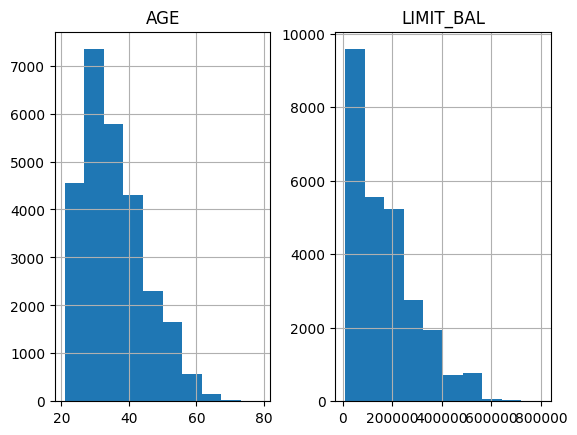

In [ ]:
df_clean_2[['AGE', 'LIMIT_BAL']].hist();

###6.3 Estatistíca Descritiva de `AGE` e `LIMIT_BAL`

In [ ]:
df_clean_2[['AGE', 'LIMIT_BAL']].describe()

,AGE,LIMIT_BAL
count,26664.000000,26664.000000
mean,35.505213,167919.054905
std,9.227442,129839.453081
min,21.000000,10000.000000
25%,28.000000,50000.000000
50%,34.000000,140000.000000
75%,41.000000,240000.000000
max,79.000000,800000.000000


###6.4 Contagem de ocorrências por categoria em `EDUCATION`

In [ ]:
df_clean_2['EDUCATION'].value_counts()

,count
EDUCATION,
2,12458
1,9412
3,4380
5,245
4,115
6,43
0,11


###6.5 Transformar o 0,5 e 6 em outros (4)

In [ ]:
df_clean_2['EDUCATION'].replace(to_replace = [0,5,6], value = 4 , inplace = True )
df_clean_2['EDUCATION'].value_counts()

/tmp/ipykernel_1157/2702344219.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean_2['EDUCATION'].replace(to_replace = [0,5,6], value = 4 , inplace = True )


,count
EDUCATION,
2,12458
1,9412
3,4380
4,414


###6.6 Contagem de ocorrências por categoria em `MARRIAGE`

In [ ]:
df_clean_2['MARRIAGE'].value_counts()

,count
MARRIAGE,
2,14158
1,12172
3,286
0,48


###6.7 Transformar 0 em outros (3)

In [ ]:
df_clean_2['MARRIAGE'].replace (to_replace = [0],value = 3, inplace = True)
df_clean_2['MARRIAGE'].value_counts()

/tmp/ipykernel_1157/4232539241.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean_2['MARRIAGE'].replace (to_replace = [0],value = 3, inplace = True)


,count
MARRIAGE,
2,14158
1,12172
3,334


### Caracteristícas Categóricas (Experimento)

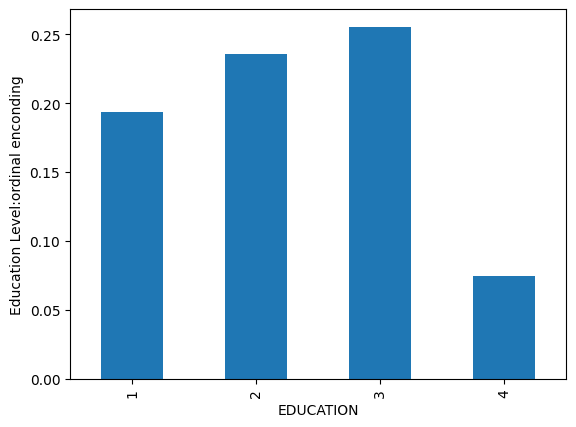

In [ ]:
df_clean_2.groupby('EDUCATION').agg({'default payment next month': 'mean' }).plot.bar(legend = False)
plt.ylabel('Default Rate')
plt.ylabel('Education Level:ordinal enconding');

In [ ]:
# Se usa o ';' para sumir o texto inútil do código!

### 7. Implementando a OHE para uma característica categorica

In [ ]:
#one hot in encoding

###7.1 Criando uma coluna vazia

In [ ]:
df_clean_2['EDUCATION_CAT'] = 'none'

### 7.2 Examinando as primeiras 10 linhas

In [ ]:
df_clean_2[['EDUCATION', 'EDUCATION_CAT']].head(10)

,EDUCATION,EDUCATION_CAT
0,2,none
1,2,none
2,2,none
3,2,none
4,2,none
5,1,none
6,1,none
7,2,none
8,3,none
9,3,none


### 7.3 Criando um dicionário de mapeamento de categorias

In [ ]:
# dicionário com chaves!
cat_mapping = {
    1: 'graduate school',
    2: 'university',
    3: 'high school',
    4: 'others'
}
cat_mapping


{1: 'graduate school', 2: 'university', 3: 'high school', 4: 'others'}

###7.4 Aplicando o mapemanto de categorias

In [ ]:
df_clean_2['EDUCATION_CAT'] = df_clean_2['EDUCATION'].map(cat_mapping)
df_clean_2[['EDUCATION', 'EDUCATION_CAT']].head(10)

,EDUCATION,EDUCATION_CAT
0,2,university
1,2,university
2,2,university
3,2,university
4,2,university
5,1,graduate school
6,1,graduate school
7,2,university
8,3,high school
9,3,high school


###7.5 Codificação de carecterísticas com OHE

In [ ]:
edu_ohe = pd.get_dummies(df_clean_2['EDUCATION_CAT'])
edu_ohe.head(10)

,graduate school,high school,others,university
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,True
4,False,False,False,True
5,True,False,False,False
6,True,False,False,False
7,False,False,False,True
8,False,True,False,False
9,False,True,False,False


###7.6 Concatetando o DataFrame original com OHE

In [ ]:
df_with_ohe = pd.concat([df_clean_2, edu_ohe],axis=1)
df_with_ohe[['EDUCATION_CAT', 'graduate school','high school', 'university', 'others']].head(10)



,EDUCATION_CAT,graduate school,high school,university,others
0,university,False,False,True,False
1,university,False,False,True,False
2,university,False,False,True,False
3,university,False,False,True,False
4,university,False,False,True,False
5,graduate school,True,False,False,False
6,graduate school,True,False,False,False
7,university,False,False,True,False
8,high school,False,True,False,False
9,high school,False,True,False,False


In [ ]:
df_clean_2.to_csv('chapter_1_cleaned_data.csv',index = False)

In [ ]:
df_clean_2.loc[df['PAY_2']==2,['PAY_2','PAY_3']].head()

,PAY_2,PAY_3
0,2,-1
1,2,0
13,2,2
15,2,0
50,2,2
